In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import time

# checking that we are using a GPU
device = 'gpu:0' if tf.test.is_gpu_available() else 'cpu'
print('using', device, 'device \n')

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
using cpu device 



In [2]:
from cosmosis.samplers.rose.nn_emulator import NNEmulator

Using CPU for computations


In [3]:
import os
dirname = os.getcwd()
print(dirname)
if os.getcwd().endswith("cosmosis-standard-library" + os.path.sep + "examples_rose" + os.path.sep + "notebooks"):
    print("Switching to directory cosmosis-standard-library")
    os.chdir(os.path.pardir)
    os.chdir(os.path.pardir)
dirname = os.getcwd()
print(dirname)

/Users/s2265800/Desktop/Work/cosmosis_stuff/cosmosis-standard-library/examples_rose/notebooks
Switching to directory cosmosis-standard-library
/Users/s2265800/Desktop/Work/cosmosis_stuff/cosmosis-standard-library


In [4]:
emu_info_file = 'output/rose_lssty1/rose_outputs/emumodel_9/lsst'
emu_info = np.load('output/rose_lssty1/rose_outputs/emumodel_9/lsst.npz', allow_pickle=True)
for key in emu_info.keys():
    print(key)
print((emu_info['data_transformation']))

architecture_type
diagnostics
parameters_mean
parameters_std
features_mean
features_std
parameters
modes
loss_function
n_hidden
weights
data_transformation
rose_vector_metadata
rose_likelihood_name
{'data_transformation': 'signed_log_norm', 'X_mean': {'cosmological_parameters--omega_m': 0.2990696622318855, 'cosmological_parameters--h0': 0.6898460718697266, 'cosmological_parameters--omega_b': 0.048944060360490496, 'cosmological_parameters--n_s': 0.9756237695322217, 'cosmological_parameters--w': -0.9857149459207378, 'cosmological_parameters--wa': -0.6453575441452475, 'cosmological_parameters--log1e10as': 2.945188295637492, 'halo_model_parameters--logt_agn': 7.68875479935922, 'bin_bias--b1': 1.346673801188953, 'bin_bias--b2': 1.4709382726529556, 'bin_bias--b3': 1.6006026454350544, 'bin_bias--b4': 1.7268036110073768, 'bin_bias--b5': 1.8652230416971283, 'intrinsic_alignment_parameters--a1': -0.39887470855482393, 'intrinsic_alignment_parameters--alpha1': 2.1605716356244904, 'photoz_source_er

In [5]:
emu = NNEmulator(model_parameters=emu_info['parameters'],
           modes=np.arange(0, len(emu_info['features_mean']), 1),
           nn_model=emu_info['architecture_type'],
           loss_function=emu_info['loss_function'],
           iteration=5,
           data_transformation=emu_info['data_transformation'])
emu.load(emu_info_file)
print(f"Data transformation: {emu.data_transformation}")

Data transformation: signed_log_norm


In [6]:
# ============================================================================
# Example: Compute gradients using autodifferentiation
# ============================================================================

# Get a sample point from the test set
# The test data contains parameter values as keys (e.g., 'omega_m', 'sigma8', etc.)


test = np.load('output/rose_lssty1/rose_outputs/total_testing_set.npz') 
params = emu_info['parameters']
sample_params = {param: [test[param][0], test[param][0]] for param in params if param in test}
Omm = sample_params['cosmological_parameters--omega_m'][0]
eps = 0.001
sample_params['cosmological_parameters--omega_m'] = [Omm, Omm+eps]
print(f"Sample params: {sample_params}")


# Make a prediction
prediction = emu.predict(sample_params)
print(f"\nPrediction shape: {prediction.shape}")
print(f"Prediction example: {[prediction[0, 0]]}")

dCl = prediction[1] - prediction[0]
print(f"dCl: {dCl[0]}")
dOmm = sample_params['cosmological_parameters--omega_m'][1] - sample_params['cosmological_parameters--omega_m'][0]
print(f"dOmm: {dOmm}")
J_order = dCl / dOmm 
print(f"J_order: {J_order[0]}")
inv_covariance = np.genfromtxt('output/lssty1_test/data_vector/lsst_inverse_covariance.txt')
print('Fisher matrix [0, 0]: ', J_order.T @ inv_covariance @ J_order)

# Compute gradients: d(prediction)/d(parameters)
# Returns shape (batch_size, n_modes, n_parameters)
# where gradient[i, j, k] = d(prediction[i, j])/d(parameter[i, k])
gradients = emu.compute_gradients(sample_params)
print(f"Gradients shape: {gradients.shape}")
print(f"Gradients shape breakdown: (batch_size={gradients.shape[0]}, n_modes={gradients.shape[1]}, n_parameters={gradients.shape[2]})")

# Access gradients for specific output mode and parameter
# For example, gradient of first output mode w.r.t. first parameter:
if len(gradients.shape) == 3 and gradients.shape[0] > 0:
    print(f"\nExample: d(prediction[0])/d({params[0]}) = {gradients[0, 0, 0]}")

# Compare with finite differences for validation
print(f"\n{'='*60}")
print("Gradient Validation: Autodiff vs Finite Differences")
print(f"{'='*60}")
if len(sample_params[params[0]]) >= 2:
    # Find which parameter changed
    for param_idx, param_name in enumerate(params):
        if param_name in sample_params:
            param_vals = sample_params[param_name]
            if len(param_vals) >= 2 and param_vals[1] != param_vals[0]:
                dparam = param_vals[1] - param_vals[0]
                dpred = prediction[1] - prediction[0]
                J_finite_diff = dpred / dparam
                
                # Get autodiff gradient for this parameter
                J_autodiff = gradients[0, :, param_idx]  # gradient of all modes w.r.t. this param
                
                print(f"\nParameter: {param_name}")
                print(f"  Finite difference: dparam = {dparam:.6e}")
                print(f"  Finite difference gradient (first mode): {J_finite_diff[0]:.6e}")
                print(f"  Autodiff gradient (first mode): {J_autodiff[0]:.6e}")
                print(f"  Ratio (autodiff/finite_diff): {J_autodiff[0]/J_finite_diff[0]:.6e}")
                
                break

# You can also compute gradients for multiple points at once
# by passing arrays instead of scalars:
sample_params_batch = {param: test[param] for param in params if param in test}

gradients_batch = emu.compute_gradients(sample_params_batch)
print(f"\nBatch gradients shape: {gradients_batch.shape}")

Sample params: {'cosmological_parameters--omega_m': [0.2950916214459268, 0.2960916214459268], 'cosmological_parameters--h0': [0.7426796040576227, 0.7426796040576227], 'cosmological_parameters--omega_b': [0.04839067098801605, 0.04839067098801605], 'cosmological_parameters--n_s': [0.951286632287237, 0.951286632287237], 'cosmological_parameters--w': [-1.0043549147623412, -1.0043549147623412], 'cosmological_parameters--wa': [0.038340276274548835, 0.038340276274548835], 'cosmological_parameters--log1e10as': [2.979256050929802, 2.979256050929802], 'halo_model_parameters--logt_agn': [7.829451846408636, 7.829451846408636], 'bin_bias--b1': [1.2295461555386267, 1.2295461555386267], 'bin_bias--b2': [1.3795912215702262, 1.3795912215702262], 'bin_bias--b3': [1.5230874603236337, 1.5230874603236337], 'bin_bias--b4': [1.680658061906041, 1.680658061906041], 'bin_bias--b5': [1.8401270343016645, 1.8401270343016645], 'intrinsic_alignment_parameters--a1': [-0.4275525819067758, -0.4275525819067758], 'intrin

In [8]:
# ============================================================================
# Fisher Matrix Example
# ============================================================================
# Likelihood Fisher: F_like = J^T * C^-1 * J
# Total Fisher (CosmoSIS convention): F = F_like + F_prior
# Gaussian priors: F_prior_ii = 1/sigma^2
# Uniform/flat ranges: no contribution to F
import yaml
import configparser

with open("examples_rose/notebooks/fiducials_lsst_w0wadesi_full.yaml", "r") as file:
    fiducial_dic = yaml.safe_load(file)
    fiducials = {k: v['p0'] for k, v in fiducial_dic.items()}
    params_dic = {k: v['latex'] for k, v in fiducial_dic.items()}
    ranges = {k: v['range'] for k, v in fiducial_dic.items()}

# Evaluate Fisher at fiducial
single_sample_params = {param: fiducials[param] for param in params}

single_gradients = emu.compute_gradients(single_sample_params)
J = single_gradients[0]  # (n_modes, n_params)

print(f"\n{'='*60}")
print("Fisher Matrix Computation")
print(f"{'='*60}")
print(f"Jacobian shape: {J.shape} (n_modes={J.shape[0]}, n_params={J.shape[1]})")

inv_covariance = np.genfromtxt('output/lssty1_test/data_vector/lsst_inverse_covariance.txt')
print(f"Covariance shape: {inv_covariance.shape}")

# Likelihood Fisher
Fisher_like = J.T @ inv_covariance @ J

# Gaussian priors from LSST Y1 CosmoSIS priors file
priors_path = 'examples_rose/lssty1/lsst_priors_y1.ini'
priors_cfg = configparser.ConfigParser()
priors_cfg.read(priors_path)

gaussian_priors = {}
for section in priors_cfg.sections():
    for key, val in priors_cfg.items(section):
        parts = val.split()
        if len(parts) >= 3 and parts[0].lower() == 'gaussian':
            gaussian_priors[f"{section}--{key}"] = float(parts[2])  # sigma

Fisher_prior = np.zeros_like(Fisher_like)
print(f"\nGaussian priors from {priors_path}:")
for i, param_name in enumerate(params):
    sigma = None
    for gp_name, gp_sigma in gaussian_priors.items():
        if gp_name.lower() == param_name.lower():
            sigma = gp_sigma
            break
    if sigma is None:
        continue
    Fisher_prior[i, i] = 1.0 / sigma**2
    print(f"  {param_name}: sigma={sigma:.6g}  ->  F_prior={1.0/sigma**2:.6g}")

Fisher_matrix = Fisher_like + Fisher_prior
print(f"\nFisher_matrix = Fisher_like + Fisher_prior")
print(f"Fisher matrix shape: {Fisher_matrix.shape}")

print(f"\nFlat prior ranges (no contribution to Fisher):")
for param_name in params:
    if param_name in ranges:
        lo, hi = ranges[param_name]
        print(f"  {param_name}: [{lo}, {hi}]")

try:
    param_covariance = np.linalg.inv(Fisher_matrix)
    param_uncertainties = np.sqrt(np.diag(param_covariance))
    param_uncertainties_like = np.sqrt(np.diag(np.linalg.inv(Fisher_like)))

    print(f"\nParameter uncertainties (like-only -> like+prior):")
    for i, param_name in enumerate(params):
        prior_note = ""
        for gp_name, sigma in gaussian_priors.items():
            if gp_name.lower() == param_name.lower():
                prior_note = f"  [gauss prior sigma={sigma:.4g}]"
                break
        print(f"  {param_name}: {param_uncertainties_like[i]:.6f} -> {param_uncertainties[i]:.6f}{prior_note}")

    print(f"\nParameter correlation matrix (like+prior):")
    param_correlation = param_covariance / np.outer(param_uncertainties, param_uncertainties)
    for i, param_i in enumerate(params):
        for j, param_j in enumerate(params):
            if j <= i:
                print(f"  {param_i} - {param_j}: {param_correlation[i, j]:.4f}")
except np.linalg.LinAlgError:
    print("Warning: Fisher matrix is singular, cannot compute uncertainties")



Fisher Matrix Computation
Jacobian shape: (489, 30) (n_modes=489, n_params=30)
Covariance shape: (489, 489)

Gaussian priors from examples_rose/lssty1/lsst_priors_y1.ini:
  photoz_source_errors--bias_1: sigma=0.0025012  ->  F_prior=159847
  photoz_source_errors--bias_2: sigma=0.002912  ->  F_prior=117928
  photoz_source_errors--bias_3: sigma=0.003309  ->  F_prior=91328.5
  photoz_source_errors--bias_4: sigma=0.0038346  ->  F_prior=68008
  photoz_source_errors--bias_5: sigma=0.0050532  ->  F_prior=39162.2
  photoz_lens_errors--bias_1: sigma=0.0065855  ->  F_prior=23058
  photoz_lens_errors--bias_2: sigma=0.007528  ->  F_prior=17645.8
  photoz_lens_errors--bias_3: sigma=0.0084995  ->  F_prior=13842.5
  photoz_lens_errors--bias_4: sigma=0.00948  ->  F_prior=11127.1
  photoz_lens_errors--bias_5: sigma=0.0104645  ->  F_prior=9131.94
  shear_calibration_parameters--m1: sigma=0.013  ->  F_prior=5917.16
  shear_calibration_parameters--m2: sigma=0.013  ->  F_prior=5917.16
  shear_calibration_p

Parameter means: [ 0.31    0.68    0.049   0.97   -0.838  -0.62    3.044   7.8     1.2497
  1.3809  1.5231  1.6716  1.8245 -0.4     2.2     0.      0.      0.
  0.      0.      0.      0.      0.      0.      0.      0.      0.
  0.      0.      0.    ]

Creating Triangular Plot


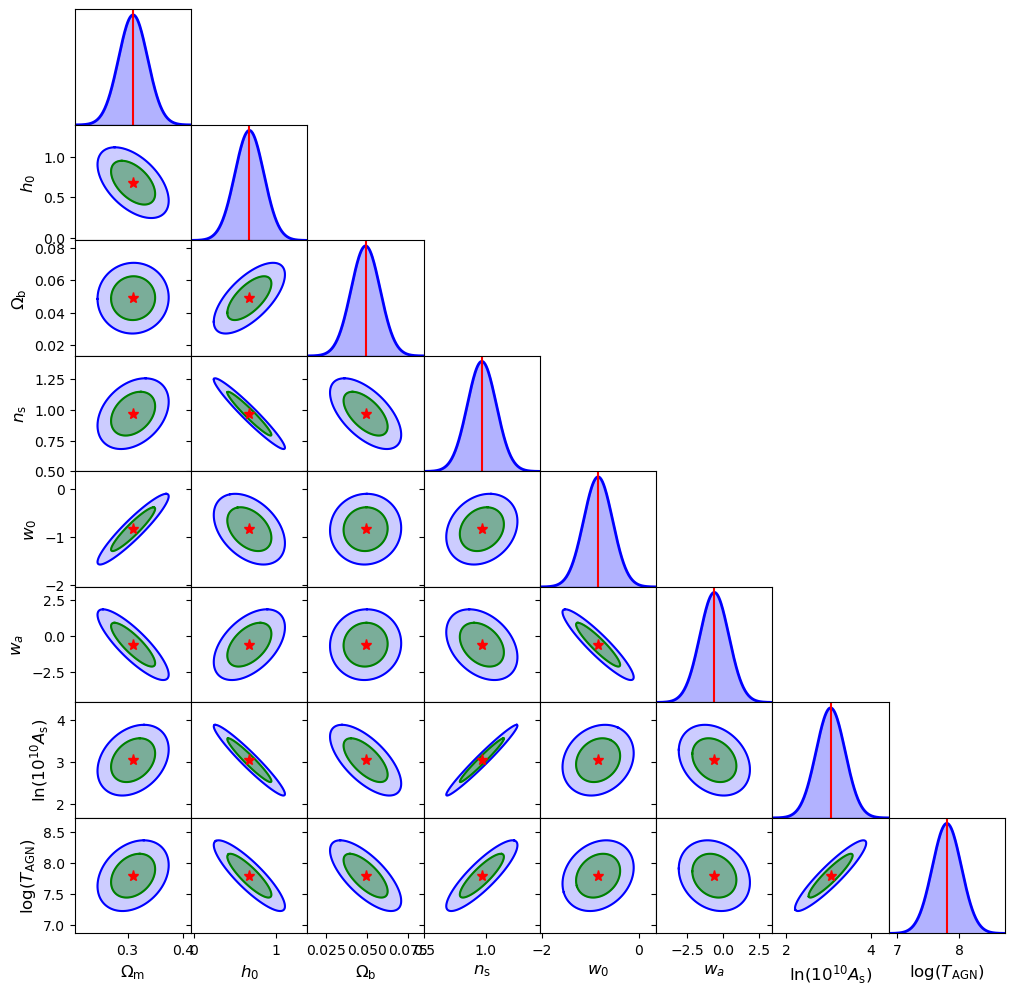

In [9]:
param_names_ = [params_dic[param] for param in params[:8]]

# Get parameter means (fiducial values)
param_means = np.array([fiducials[param] for param in params])
print(f"Parameter means: {param_means}")

print(f"\n{'='*60}")
print("Creating Triangular Plot")
print(f"{'='*60}")
title = "Fisher Matrix Constraints"
n_params = len(param_names_)
param_stds = np.sqrt(np.diag(param_covariance))
# Shared axis limits per parameter (getdist-style alignment across rows/cols)
param_lims = [(m - 4 * s, m + 4 * s) for m, s in zip(param_means, param_stds)]

fig, axes = plt.subplots(
    n_params, n_params,
    figsize=(1.5 * n_params, 1.5 * n_params),
)
fig.subplots_adjust(hspace=0, wspace=0)


# Chi-squared values for 2D Gaussian confidence levels
chi2_68 = 2.3
chi2_95 = 6.0

for i in range(n_params):
    for j in range(n_params):
        ax = axes[i, j]

        if i < j:
            ax.axis('off')
            continue

        if i == j:
            # Diagonal: 1D marginalized Gaussian
            param_mean = param_means[i]
            param_std = param_stds[i]
            x_range = np.linspace(*param_lims[i], 200)
            y = np.exp(-0.5 * ((x_range - param_mean) / param_std)**2) / (param_std * np.sqrt(2 * np.pi))

            ax.plot(x_range, y, 'b-', linewidth=2)
            ax.fill_between(x_range, 0, y, alpha=0.3, color='blue')
            ax.axvline(param_mean, color='red', linestyle='-', linewidth=1.5)

            ax.set_xlim(param_lims[i])
            ax.set_ylim(bottom=0)
            # Hide y ticks/labels on 1D panels (density scale is not shared)
            ax.tick_params(axis='y', labelleft=False, left=False)
        else:
            # Lower triangle: 2D contours (getdist: x = param j, y = param i)
            cov_2d = param_covariance[[j, i], :][:, [j, i]]
            mean_2d = np.array([param_means[j], param_means[i]])

            eigenvals, eigenvecs = np.linalg.eigh(cov_2d)
            order = eigenvals.argsort()[::-1]
            eigenvals = eigenvals[order]
            eigenvecs = eigenvecs[:, order]
            angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))

            for chi2, color, alpha in [(chi2_95, 'blue', 0.2), (chi2_68, 'green', 0.4)]:
                width = 2 * np.sqrt(chi2 * eigenvals[0])
                height = 2 * np.sqrt(chi2 * eigenvals[1])
                theta = np.linspace(0, 2 * np.pi, 100)
                ellipse = np.array([width / 2 * np.cos(theta), height / 2 * np.sin(theta)])
                R = np.array([[np.cos(np.radians(angle)), -np.sin(np.radians(angle))],
                              [np.sin(np.radians(angle)),  np.cos(np.radians(angle))]])
                ellipse_rot = R @ ellipse
                ex = ellipse_rot[0] + mean_2d[0]
                ey = ellipse_rot[1] + mean_2d[1]
                ax.plot(ex, ey, color=color, linewidth=1.5)
                ax.fill(ex, ey, color=color, alpha=alpha)

            ax.plot(mean_2d[0], mean_2d[1], 'r*', markersize=8)
            ax.set_xlim(param_lims[j])
            ax.set_ylim(param_lims[i])

        # Labels / tick numbers only on the outside (bottom row + left column)
        if i == n_params - 1:
            ax.set_xlabel(r'$' + param_names_[j] + r'$' if not param_names_[j].startswith('$') else param_names_[j], fontsize=12)
            ax.tick_params(axis='x', labelbottom=True)
        else:
            ax.set_xlabel('')
            ax.tick_params(axis='x', labelbottom=False)

        if j == 0 and i > 0:
            ax.set_ylabel(r'$' + param_names_[i] + r'$' if not str(param_names_[i]).startswith('$') else param_names_[i], fontsize=12)
            ax.tick_params(axis='y', labelleft=True)
        elif i != j:
            ax.set_ylabel('')
            ax.tick_params(axis='y', labelleft=False)

plt.show()
